In [1]:
import netrd
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np
# Monkey patch NumPy 2.0 to support old netrd code
if not hasattr(np, 'float'):
    np.float = float

q1 - Network Reconstruction

c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\utilities\threshold.py:40: RuntimeWarning: Setting 'cutoffs' argument is strongly encouraged. Using cutoff range of (-1, 1).
  warnings.warn(
c:\Users\User\anaconda3\envs\school\lib\site-packages\netrd\reconstruction\partial_correlation_matrix.py:173: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = stats.pearsonr(res_i, res_j)[0]
c:\Users\User\anaconda3\envs\school\lib\site-packages\numpy\lib\_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in <lambda> (vectorized)
  outputs = ufunc(*inputs)


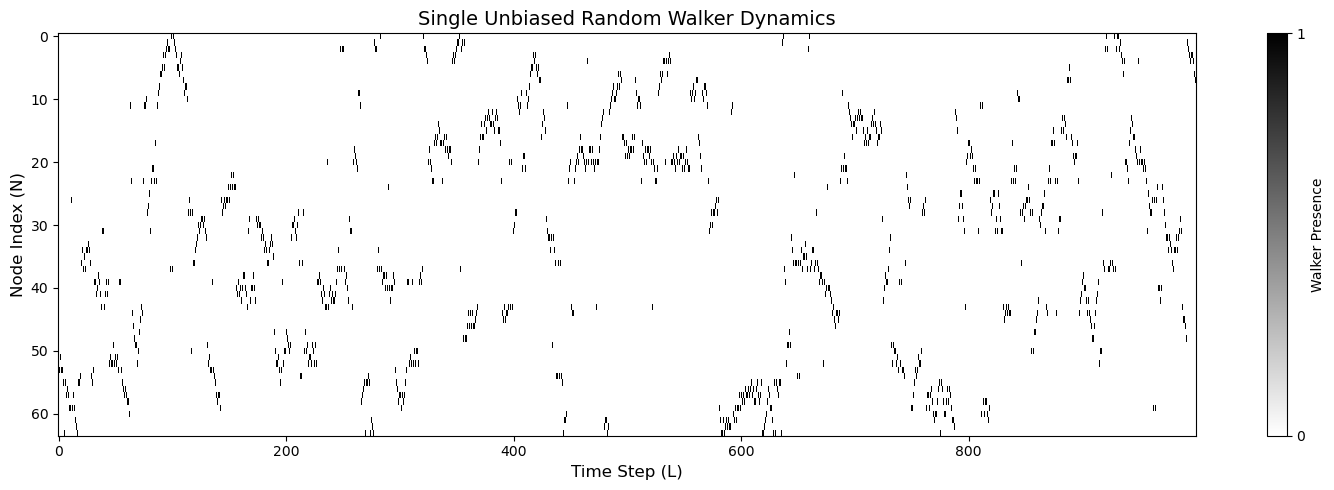

In [ ]:
G = nx.watts_strogatz_graph(64, 4, .25)

# --- run sim ---

model = netrd.dynamics.SingleUnbiasedRandomWalker()
sim_results = {}
available = list(G.nodes())
for i in range(20):
    seed = random.choice(available)
    tseries = model.simulate(G, 1000, seed)
    H = model.results['ground_truth']
    sim_results[seed] = (tseries, H)
    available.remove(seed)

# --- visualize 1st time-series matrix ---

# retrieve 1st element from 1st tuple
mat_to_show = next(iter(sim_results.values()))[0]

# plot
plt.figure(figsize=(15, 5))
plt.imshow(mat_to_show, 
           aspect='auto',
           cmap='binary',
           interpolation='none')

# aesthetics
plt.colorbar(label='Walker Presence', ticks=[0, 1])
plt.title('Single Unbiased Random Walker Dynamics', fontsize=14)
plt.xlabel('Time Step (L)', fontsize=12)
plt.ylabel('Node Index (N)', fontsize=12)

plt.tight_layout()
plt.savefig('imgs/randwalk_timeseries.png')

In [ ]:
# --- reconstruction ---

recon = netrd.reconstruction.PartialCorrelationMatrix()

# loop
recon_results = {}
for seed, (tseries, H) in sim_results.items():
    G_recon = recon.fit(tseries)
    recon_results[seed] = (G_recon, H)

# custom threshold version
recon_results_thr = {}
for seed, (tseries, H) in sim_results.items():
    G_recon = recon.fit(tseries, threshold_type='degree', avg_k=15)
    recon_results_thr[seed] = (G_recon, H)

In [ ]:
# --- evaluation ---



simulate dynamics on known graph, then reconstruct the graph using the observed time series and evaluate quality of reconstruction.
- useful to distinguish between edge-score matrix S (evidence for edges) and reconstructed adjacency A-hat (likely created by thresholding S)